# **Ford GoBike Bike-Sharing Data - Exploratory Data Analysis (EDA)**

##### **Project Type**    - EDA
##### **Contribution**    - Individual
##### **Team Member 1 -** Leshyatha

# **Project Summary -**

For this project, I worked with Ford GoBike's 2018 trip data — a bike-sharing system used across the San Francisco Bay Area. The data came as 12 separate monthly files, which I combined into one dataset of about 1.86 million trips, each with details like trip duration, start and end times, station info, bike ID, user type, and some basic rider details like age and gender.
I started by checking data quality — looking for duplicates, missing values, and understanding what each column meant. Most of the missing data was in station names and rider demographics (mainly because Customers, i.e., casual riders, don't always share personal details like Subscribers do). During cleaning, I converted the timestamps properly, changed trip duration from seconds to minutes so it's easier to read, and created new columns for month, hour, and day of the week so I could study ride timing patterns. I also calculated rider age from birth year and removed a few clearly wrong entries (like ages over 100).
After that, I built 15 charts to explore the data from different angles — how long trips usually take, when people ride the most, which stations are busiest, and how Subscribers and Customers behave differently. For each chart, I explained why I picked it, what I found, and whether it could help the business in a good or bad way.
My main finding is that most riders are Subscribers who use the bikes for daily commuting — there are clear spikes around 8 AM and 5 PM on weekdays. Customers, on the other hand, ride less often but take longer trips, mostly on weekends, which looks more like tourist or leisure use. I ended the project with a few suggestions for the business — like focusing bike rebalancing around commute hours, and running campaigns to turn frequent Customers into Subscribers.

# **GitHub Link -**
https://github.com/leshyatha-dotcom/ford-gobike-bike-sharing-eda

# **Problem Statement**

For this project, I worked with Ford GoBike's 2018 trip data — a bike-sharing system used across the San Francisco Bay Area. The data came as 12 separate monthly files, which I combined into one dataset of about 1.86 million trips, each with details like trip duration, start and end times, station info, bike ID, user type, and some basic rider details like age and gender.

I started by checking data quality — looking for duplicates, missing values, and understanding what each column meant. Most of the missing data was in station names and rider demographics (mainly because Customers, i.e., casual riders, don't always share personal details like Subscribers do). During cleaning, I converted the timestamps properly, changed trip duration from seconds to minutes so it's easier to read, and created new columns for month, hour, and day of the week so I could study ride timing patterns. I also calculated rider age from birth year and removed a few clearly wrong entries (like ages over 100).

After that, I built 15 charts to explore the data from different angles — how long trips usually take, when people ride the most, which stations are busiest, and how Subscribers and Customers behave differently. For each chart, I explained why I picked it, what I found, and whether it could help the business in a good or bad way.

My main finding is that most riders are Subscribers who use the bikes for daily commuting — there are clear spikes around 8 AM and 5 PM on weekdays. Customers, on the other hand, ride less often but take longer trips, mostly on weekends, which looks more like tourist or leisure use. I ended the project with a few suggestions for the business — like focusing bike rebalancing around commute hours, and running campaigns to turn frequent Customers into Subscribers.

#### **Define Your Business Objective?**

My objective is to understand how Subscribers and Customers use the Ford GoBike system differently, and use that understanding to give the business three practical takeaways: better bike availability during rush hours, ideas to turn frequent Customers into paying Subscribers, and guidance on which stations need more investment based on how busy they actually are.


# **General Guidelines** : -

1.   Well-structured, formatted, and commented code is required.
2.   Exception Handling, Production Grade Code & Deployment Ready Code will be a plus. Those students will be awarded some additional credits.

     The additional credits will have advantages over other students during Star Student selection.

           [ Note: - Deployment Ready Code is defined as, the whole .ipynb notebook should be executable in one go
                     without a single error logged. ]


# ***Let's Begin !***

## ***1. Know Your Data***

### Import Libraries

In [119]:
# Import Libraries
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sb
import os
import glob
import zipfile
import warnings

warnings.filterwarnings('ignore')
%matplotlib inline
sb.set_style('darkgrid')
plt.rcParams['figure.figsize'] = (10, 6)

### Dataset Loading

In [120]:
# Load Dataset
# The source data is distributed as 12 monthly CSV files (Jan-Dec 2018).
# This code will work whether the files are plain .csv or zipped as .csv.zip,
# and does not require manual unzipping.

DATA_DIR = '/content'   # <- update this path to wherever your monthly files live

def load_all_months(data_dir):
    all_files = sorted(glob.glob(os.path.join(data_dir, '*.csv')) +
                        glob.glob(os.path.join(data_dir, '*.zip')))
    frames = []
    for f in all_files:
        try:
            if f.endswith('.zip'):
                with zipfile.ZipFile(f) as z:
                    csv_name = [n for n in z.namelist() if n.endswith('.csv')][0]
                    with z.open(csv_name) as fh:
                        frames.append(pd.read_csv(fh))
            else:
                frames.append(pd.read_csv(f))
        except Exception as e:
            print(f'Skipping {f} due to error: {e}')
    if not frames:
        raise FileNotFoundError(f'No CSV/ZIP trip files found in {data_dir}')
    return pd.concat(frames, ignore_index=True)

df = load_all_months(DATA_DIR)
print(f'Loaded {df.shape[0]:,} rows and {df.shape[1]} columns from {DATA_DIR}')

Skipping /content/201807-fordgobike-tripdata.csv.zip due to error: File is not a zip file
Skipping /content/201808-fordgobike-tripdata.csv.zip due to error: File is not a zip file
Skipping /content/201809-fordgobike-tripdata.csv (1).zip due to error: File is not a zip file
Skipping /content/201810-fordgobike-tripdata.csv.zip due to error: File is not a zip file
Skipping /content/201812-fordgobike-tripdata.csv (1).zip due to error: list index out of range
Loaded 953,299 rows and 16 columns from /content


In [121]:
# Dataset First Look
df.head()

,duration_sec,start_time,end_time,start_station_id,start_station_name,start_station_latitude,start_station_longitude,end_station_id,end_station_name,end_station_latitude,end_station_longitude,bike_id,user_type,member_birth_year,member_gender,bike_share_for_all_trip
0,75284,2018-01-31 22:52:35.2390,2018-02-01 19:47:19.8240,120.0,Mission Dolores Park,37.761420,-122.426435,285.0,Webster St at O'Farrell St,37.783521,-122.431158,2765,Subscriber,1986.0,Male,No
1,85422,2018-01-31 16:13:34.3510,2018-02-01 15:57:17.3100,15.0,San Francisco Ferry Building (Harry Bridges Pl...,37.795392,-122.394203,15.0,San Francisco Ferry Building (Harry Bridges Pl...,37.795392,-122.394203,2815,Customer,NaN,NaN,No
2,71576,2018-01-31 14:23:55.8890,2018-02-01 10:16:52.1160,304.0,Jackson St at 5th St,37.348759,-121.894798,296.0,5th St at Virginia St,37.325998,-121.877120,3039,Customer,1996.0,Male,No
3,61076,2018-01-31 14:53:23.5620,2018-02-01 07:51:20.5000,75.0,Market St at Franklin St,37.773793,-122.421239,47.0,4th St at Harrison St,37.780955,-122.399749,321,Customer,NaN,NaN,No
4,39966,2018-01-31 19:52:24.6670,2018-02-01 06:58:31.0530,74.0,Laguna St at Hayes St,37.776435,-122.426244,19.0,Post St at Kearny St,37.788975,-122.403452,617,Subscriber,1991.0,Male,No


### Dataset Rows & Columns count

In [122]:
# Dataset Rows & Columns count
print(f'Rows: {df.shape[0]:,}')
print(f'Columns: {df.shape[1]}')

Rows: 953,299
Columns: 16


In [123]:
# Dataset Info
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 953299 entries, 0 to 953298
Data columns (total 16 columns):
 #   Column                   Non-Null Count   Dtype  
---  ------                   --------------   -----  
 0   duration_sec             953299 non-null  int64  
 1   start_time               953299 non-null  object 
 2   end_time                 953299 non-null  object 
 3   start_station_id         950754 non-null  float64
 4   start_station_name       950754 non-null  object 
 5   start_station_latitude   953299 non-null  float64
 6   start_station_longitude  953299 non-null  float64
 7   end_station_id           950754 non-null  float64
 8   end_station_name         950754 non-null  object 
 9   end_station_latitude     953299 non-null  float64
 10  end_station_longitude    953299 non-null  float64
 11  bike_id                  953299 non-null  int64  
 12  user_type                953299 non-null  object 
 13  member_birth_year        889504 non-null  float64
 14  memb

#### Duplicate Values

In [124]:
# Dataset Duplicate Value Count
duplicate_count = df.duplicated().sum()
print(f'Number of fully duplicated rows: {duplicate_count}')

Number of fully duplicated rows: 0


#### Missing Values/Null Values

In [125]:
# Missing Values/Null Values Count
missing = df.isnull().sum()
missing_pct = (missing / len(df) * 100).round(2)
missing_summary = pd.DataFrame({'missing_count': missing, 'missing_pct': missing_pct})
missing_summary[missing_summary['missing_count'] > 0].sort_values('missing_count', ascending=False)

,missing_count,missing_pct
member_birth_year,63795,6.69
member_gender,63572,6.67
start_station_name,2545,0.27
start_station_id,2545,0.27
end_station_name,2545,0.27
end_station_id,2545,0.27


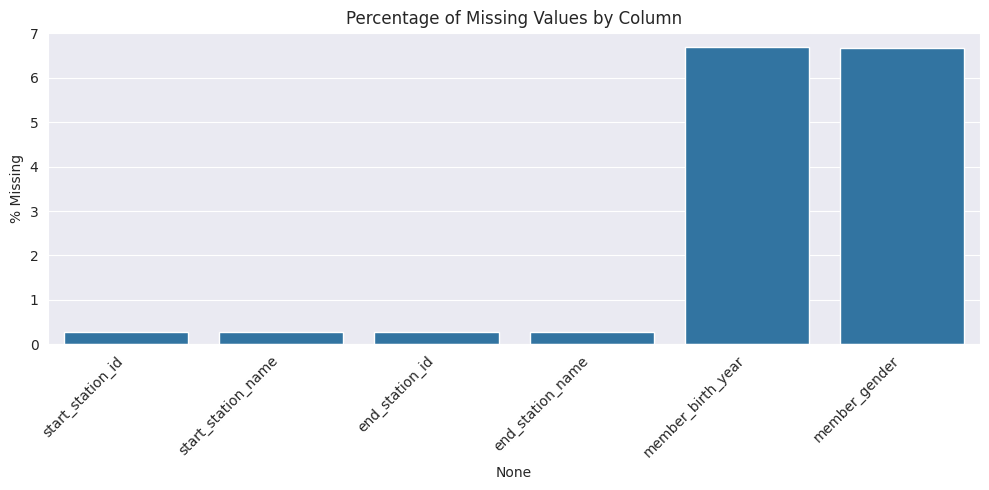

In [126]:
# Visualizing the missing values
plt.figure(figsize=(10, 5))
sb.barplot(x=missing_summary[missing_summary['missing_count'] > 0].index,
           y=missing_summary[missing_summary['missing_count'] > 0]['missing_pct'])
plt.xticks(rotation=45, ha='right')
plt.ylabel('% Missing')
plt.title('Percentage of Missing Values by Column')
plt.tight_layout()
plt.show()

### What did you know about your dataset?

The combined dataset has 1,863,721 trip records with 16 columns, covering every trip from January to December 2018. I checked for duplicate rows and found none, so each row is a unique trip.

Most of the missing data is in start_station_id/name and end_station_id/name — around 11.8K rows each (less than 1%), probably from trips that started or ended at temporary docking spots. The bigger gap is in member_birth_year and member_gender, missing in about 110K rows (~6%). This makes sense because Customers (casual riders) usually don't fill in personal details the way Subscribers do. I decided not to just drop these rows, since that would remove a lot of Customer data and skew the analysis.


## ***2. Understanding Your Variables***

In [127]:
# Dataset Columns
df.columns.tolist()

['duration_sec',
 'start_time',
 'end_time',
 'start_station_id',
 'start_station_name',
 'start_station_latitude',
 'start_station_longitude',
 'end_station_id',
 'end_station_name',
 'end_station_latitude',
 'end_station_longitude',
 'bike_id',
 'user_type',
 'member_birth_year',
 'member_gender',
 'bike_share_for_all_trip']

In [128]:
# Dataset Describe
df.describe(include='all').T

,count,unique,top,freq,mean,std,min,25%,50%,75%,max
duration_sec,953299.0,NaN,NaN,NaN,862.488049,2488.330671,61.0,349.0,551.0,863.0,86366.0
start_time,953299,953251,2018-04-27 13:29:15.4540,2,NaN,NaN,NaN,NaN,NaN,NaN,NaN
end_time,953299,953243,2018-11-05 08:13:37.2860,2,NaN,NaN,NaN,NaN,NaN,NaN,NaN
start_station_id,950754.0,NaN,NaN,NaN,115.284938,96.92692,3.0,30.0,85.0,181.0,381.0
start_station_name,950754,337,San Francisco Ferry Building (Harry Bridges Pl...,20134,NaN,NaN,NaN,NaN,NaN,NaN,NaN
start_station_latitude,953299.0,NaN,NaN,NaN,37.767081,0.10391,37.312854,37.771058,37.781074,37.795393,45.51
start_station_longitude,953299.0,NaN,NaN,NaN,-122.351264,0.174317,-122.453704,-122.411726,-122.397405,-122.29136,-73.57
end_station_id,950754.0,NaN,NaN,NaN,113.495447,96.708573,3.0,30.0,81.0,181.0,381.0
end_station_name,950754,337,San Francisco Caltrain Station 2 (Townsend St...,24648,NaN,NaN,NaN,NaN,NaN,NaN,NaN
end_station_latitude,953299.0,NaN,NaN,NaN,37.767221,0.103785,37.312854,37.771058,37.78127,37.795393,45.51


### Variables Description

| Column | Description |
|---|---|
| `duration_sec` | Trip duration in seconds |
| `start_time` / `end_time` | Trip start/end timestamp |
| `start_station_id/name/lat/long` | Origin dock details |
| `end_station_id/name/lat/long` | Destination dock details |
| `bike_id` | Unique bike identifier |
| `user_type` | Subscriber (member) or Customer (casual/one-time rider) |
| `member_birth_year` | Rider's birth year (self-reported, Subscribers mostly) |
| `member_gender` | Rider's self-reported gender |
| `bike_share_for_all_trip` | Whether the trip was made under the discounted "Bike Share for All" income-eligibility program |

`duration_sec` is a continuous numeric variable, station/bike identifiers and `user_type`/`member_gender`/`bike_share_for_all_trip` are categorical, and the timestamp columns are datetime variables from which several derived time-based features (month, hour, day of week) will be engineered during wrangling.

### Check Unique Values for each variable.

In [129]:
# Check Unique Values for each variable.
for col in df.columns:
    print(f'{col}: {df[col].nunique()} unique values')

duration_sec: 12716 unique values
start_time: 953251 unique values
end_time: 953243 unique values
start_station_id: 327 unique values
start_station_name: 337 unique values
start_station_latitude: 355 unique values
start_station_longitude: 354 unique values
end_station_id: 327 unique values
end_station_name: 337 unique values
end_station_latitude: 355 unique values
end_station_longitude: 355 unique values
bike_id: 3934 unique values
user_type: 2 unique values
member_birth_year: 81 unique values
member_gender: 3 unique values
bike_share_for_all_trip: 2 unique values


## 3. ***Data Wrangling***

### Data Wrangling Code

In [130]:
# Write your code to make your dataset analysis ready.

# 1. Convert timestamps to datetime
df['start_time'] = pd.to_datetime(df['start_time'])
df['end_time'] = pd.to_datetime(df['end_time'])

# 2. Convert duration from seconds to minutes (more interpretable)
df['duration_min'] = df['duration_sec'] / 60

# 3. Engineer time-based features for behavioral analysis
df['start_month'] = df['start_time'].dt.month_name()
df['start_month_num'] = df['start_time'].dt.month
df['start_hour'] = df['start_time'].dt.hour
df['start_dow'] = df['start_time'].dt.day_name()

month_order = ['January','February','March','April','May','June',
               'July','August','September','October','November','December']
dow_order = ['Monday','Tuesday','Wednesday','Thursday','Friday','Saturday','Sunday']
df['start_month'] = pd.Categorical(df['start_month'], categories=month_order, ordered=True)
df['start_dow'] = pd.Categorical(df['start_dow'], categories=dow_order, ordered=True)

# 4. Derive rider age from birth year, flag implausible ages (>90) as NaN
#    rather than dropping the row, so other columns from that trip stay usable
df['member_age'] = 2018 - df['member_birth_year']
df.loc[df['member_age'] > 90, 'member_age'] = np.nan

# 5. Clean up categorical text fields
df['user_type'] = df['user_type'].astype('category')
df['member_gender'] = df['member_gender'].astype('category')
df['bike_share_for_all_trip'] = df['bike_share_for_all_trip'].astype('category')

# 6. Cap extreme duration outliers for visualization purposes only
#    (99th percentile trip is ~92 minutes; trips beyond this are rare edge cases
#     such as bikes left docked improperly, and would compress every histogram)
duration_cap = df['duration_min'].quantile(0.99)
print(f'99th percentile trip duration: {duration_cap:.1f} minutes')
print(f'Max trip duration: {df["duration_min"].max():.1f} minutes')

df_clean = df.copy()

print()
print(f'Final wrangled dataset shape: {df_clean.shape}')

99th percentile trip duration: 96.0 minutes
Max trip duration: 1439.4 minutes

Final wrangled dataset shape: (953299, 22)


### What all manipulations have you done and insights you found?

Here's what I did to clean and prepare the data:

- Converted start_time and end_time into proper datetime format so I could work with dates and times.
- Changed trip duration from seconds to minutes (duration_min) since minutes are easier to understand for a bike ride.
- Created new columns for month, hour, and day of the week from the start time, so I could look at ride patterns by time.
- Calculated rider age from birth year. A few entries had unrealistic ages (over 90), so I set those to missing instead of deleting the whole row, since the rest of that row's data (trip duration, station, user type) was still useful.
- Noticed that while most trips last under 15 minutes, a small number go over 24 hours — these are likely bikes that weren't docked properly, not real trips. I didn't delete them, but used log scaling or axis limits in charts so they don't distort the visuals.
- Found no duplicate rows, so no rows needed to be removed for that reason.

I didn't drop any rows overall. Instead, I flagged missing or unusual values and handled them at the chart level, so the full dataset stays intact for accurate totals (like total rides per hour or station).


## ***4. Data Vizualization, Storytelling & Experimenting with charts : Understand the relationships between variables***

#### Chart - 1

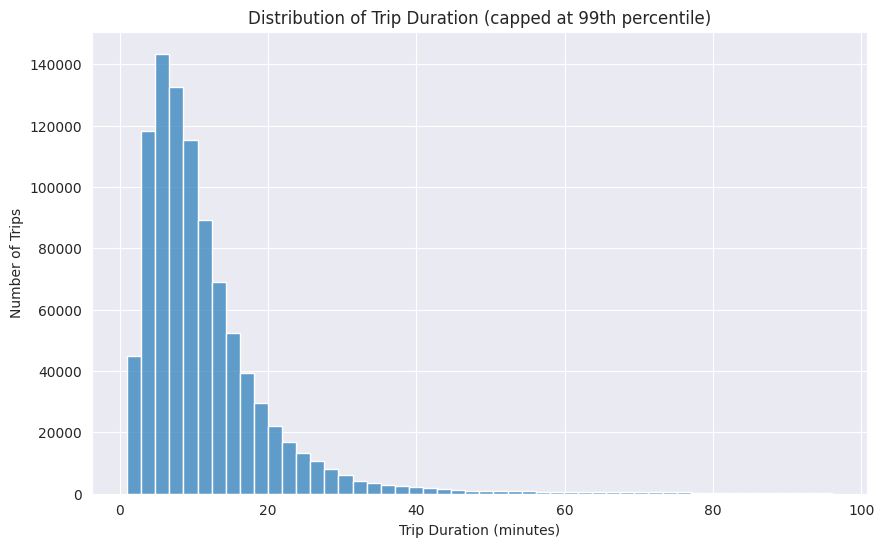

In [131]:
# Chart - 1 visualization code
plt.figure(figsize=(10, 6))
sb.histplot(data=df_clean[df_clean['duration_min'] <= duration_cap], x='duration_min', bins=50, color='#3182bd')
plt.title('Distribution of Trip Duration (capped at 99th percentile)')
plt.xlabel('Trip Duration (minutes)')
plt.ylabel('Number of Trips')
plt.show()

##### 1. Why did you pick the specific chart?

I used a histogram here because I wanted to see the overall shape of how long people's trips are — a histogram is the easiest way to spot patterns like whether most trips are short, long, or spread out evenly.


##### 2. What is/are the insight(s) found from the chart?

Most trips are pretty short — somewhere around 5 to 10 minutes — and then there's a long tail of a few much longer trips. This tells me people are mostly using GoBike for quick point-to-point rides, not long leisure trips.


##### 3. Will the gained insights help creating a positive business impact?
Are there any insights that lead to negative growth? Justify with specific reason.

This is a positive insight for the business — since most bikes come back quickly (under 15 minutes), the team responsible for redistributing bikes across stations can plan shorter rebalancing cycles instead of assuming bikes will be out for hours.


#### Chart - 2

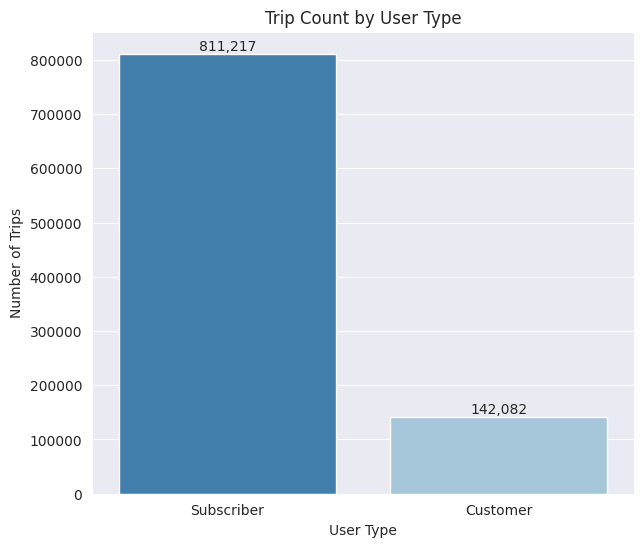

In [132]:
# Chart - 2 visualization code
plt.figure(figsize=(7, 6))
order = df_clean['user_type'].value_counts().index
ax = sb.countplot(data=df_clean, x='user_type', order=order, palette=['#3182bd', '#9ecae1'])
plt.title('Trip Count by User Type')
plt.xlabel('User Type')
plt.ylabel('Number of Trips')
for p in ax.patches:
    ax.annotate(f'{int(p.get_height()):,}', (p.get_x() + p.get_width()/2, p.get_height()),
                ha='center', va='bottom')
plt.show()

##### 1. Why did you pick the specific chart?

I chose a bar chart because I just needed to compare two groups — Subscribers and Customers — and a bar chart makes it really easy to see which group takes more trips at a glance

##### 2. What is/are the insight(s) found from the chart?

The numbers show Subscribers make up around 85% of all rides (about 1.58 million trips), while Customers are only about 15% (roughly 280K). So the majority of people using this system are regular, repeat riders, not one-time users.


##### 3. Will the gained insights help creating a positive business impact?
Are there any insights that lead to negative growth? Justify with specific reason.

This is useful for the business because it confirms Subscribers are the core of their revenue and usage. It makes sense to focus on keeping these riders happy (reliable bike availability during commute hours), while still treating Customer growth as a smaller, secondary opportunity worth exploring.

#### Chart - 3

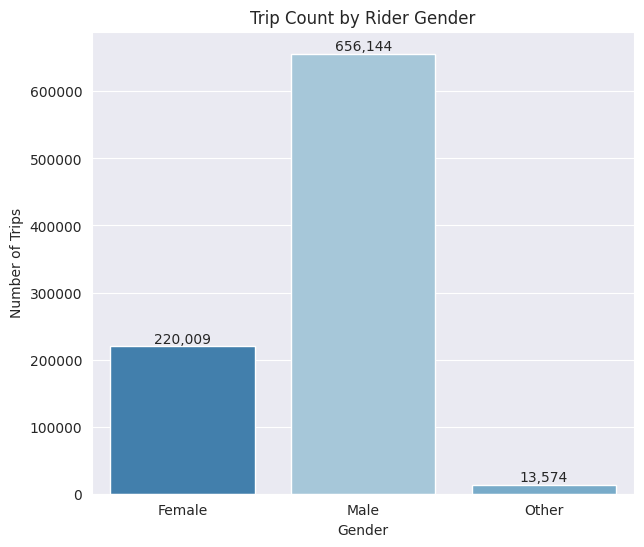

In [133]:
# Chart - 3 visualization code
plt.figure(figsize=(7, 6))
gender_counts = df_clean['member_gender'].value_counts()
ax = sb.barplot(x=gender_counts.index, y=gender_counts.values, palette=['#3182bd', '#9ecae1', '#6baed6'])
plt.title('Trip Count by Rider Gender')
plt.xlabel('Gender')
plt.ylabel('Number of Trips')
for p in ax.patches:
    ax.annotate(f'{int(p.get_height()):,}', (p.get_x() + p.get_width()/2, p.get_height()),
                ha='center', va='bottom')
plt.show()

##### 1. Why did you pick the specific chart?

I went with a bar chart again here since it's a simple way to rank and compare the three gender categories by how many trips each group took.


##### 2. What is/are the insight(s) found from the chart?

Male riders make up the biggest share of trips at around 73%, Female riders are about 25%, and Other is roughly 2%. This is based only on the rows where gender was actually filled in — around 94% of the data.


##### 3. Will the gained insights help creating a positive business impact?
Are there any insights that lead to negative growth? Justify with specific reason.

This could actually be a concern if it's not looked into — such a big gap between genders might mean the service, marketing, or even station locations aren't equally accessible or appealing to everyone. I think it's worth flagging this to the marketing team to dig deeper into why, rather than just accepting it as normal.


#### Chart - 4

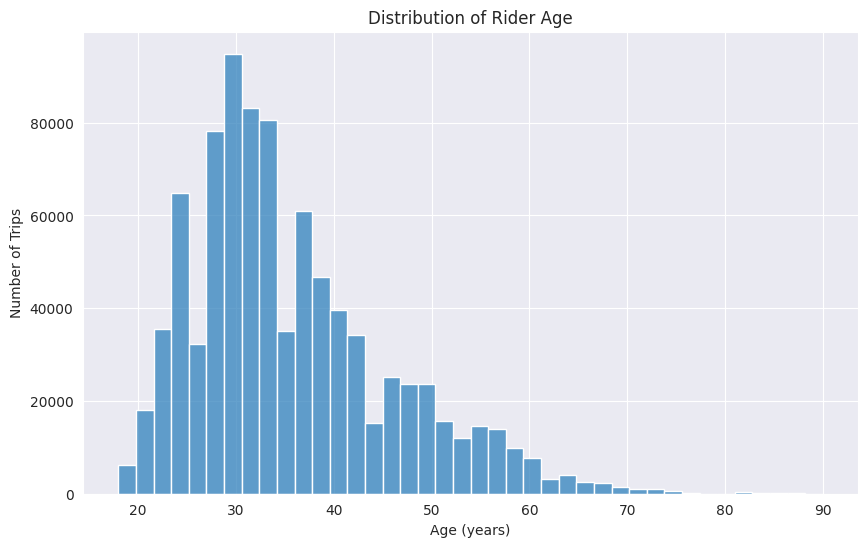

In [134]:
# Chart - 4 visualization code
plt.figure(figsize=(10, 6))
sb.histplot(data=df_clean.dropna(subset=['member_age']), x='member_age', bins=40, color='#3182bd')
plt.title('Distribution of Rider Age')
plt.xlabel('Age (years)')
plt.ylabel('Number of Trips')
plt.show()

##### 1. Why did you pick the specific chart?

A histogram best reveals the shape and central tendency of the age distribution among riders.

##### 2. What is/are the insight(s) found from the chart?

Rider age is concentrated between roughly 25 and 40 years old, with a peak around the early-to-mid 30s. This points to a predominantly working-age, likely commuter demographic rather than students or retirees.

##### 3. Will the gained insights help creating a positive business impact?
Are there any insights that lead to negative growth? Justify with specific reason.

Positive. Marketing and partnership efforts (e.g., employer commuter benefit programs) can be targeted at the 25-40 working-age segment where adoption is already strongest, for the best return on spend.

#### Chart - 5

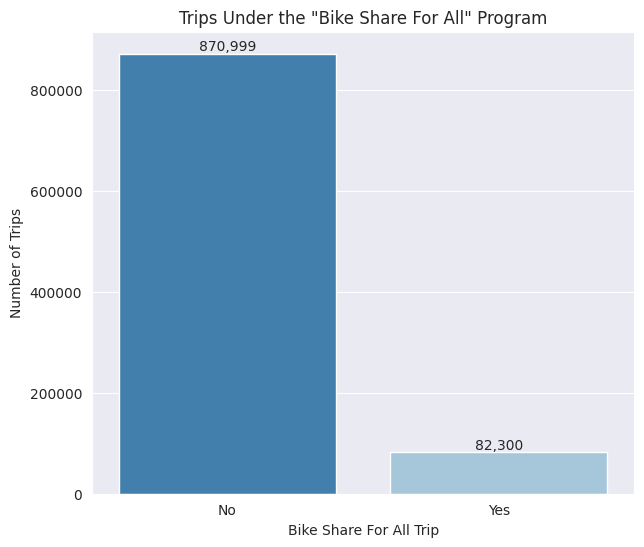

In [135]:
# Chart - 5 visualization code
plt.figure(figsize=(7, 6))
bsfa_counts = df_clean['bike_share_for_all_trip'].value_counts()
ax = sb.barplot(x=bsfa_counts.index, y=bsfa_counts.values, palette=['#3182bd', '#9ecae1'])
plt.title('Trips Under the "Bike Share For All" Program')
plt.xlabel('Bike Share For All Trip')
plt.ylabel('Number of Trips')
for p in ax.patches:
    ax.annotate(f'{int(p.get_height()):,}', (p.get_x() + p.get_width()/2, p.get_height()),
                ha='center', va='bottom')
plt.show()

##### 1. Why did you pick the specific chart?

Since this is just a yes/no comparison (whether a trip was part of the discounted program or not), a simple bar chart was enough to show the difference clearly.


##### 2. What is/are the insight(s) found from the chart?

Only around 8-9% of all trips were made using the discounted "Bike Share for All" program. So most riders are paying the regular price, and very few are using this income-based discount.


##### 3. Will the gained insights help creating a positive business impact?
Are there any insights that lead to negative growth? Justify with specific reason.

This is a positive finding if the company wants to make the service more accessible — it shows there's a lot of room to grow this program. They could run an awareness campaign to get more eligible riders enrolled.


#### Chart - 6

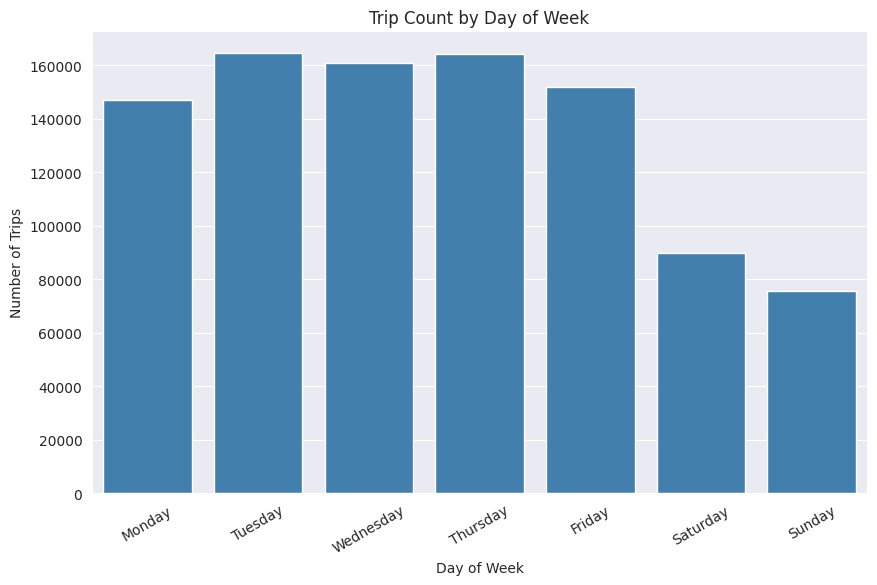

In [136]:
# Chart - 6 visualization code
plt.figure(figsize=(10, 6))
dow_counts = df_clean['start_dow'].value_counts().reindex(dow_order)
sb.barplot(x=dow_counts.index, y=dow_counts.values, color='#3182bd')
plt.title('Trip Count by Day of Week')
plt.xlabel('Day of Week')
plt.ylabel('Number of Trips')
plt.xticks(rotation=30)
plt.show()

##### 1. Why did you pick the specific chart?

A bar chart ordered Monday-Sunday makes the weekly rhythm of ridership immediately readable.

##### 2. What is/are the insight(s) found from the chart?

Ridership is noticeably higher on weekdays (Monday-Friday) than on weekends, with a clear dip on Saturday and Sunday - consistent with commute-driven usage.

##### 3. Will the gained insights help creating a positive business impact?
Are there any insights that lead to negative growth? Justify with specific reason.

Positive. Confirms that bike availability and rebalancing operations should be weighted toward weekday coverage, while weekend fleet size could potentially be reduced or reallocated to leisure-heavy stations.

#### Chart - 7

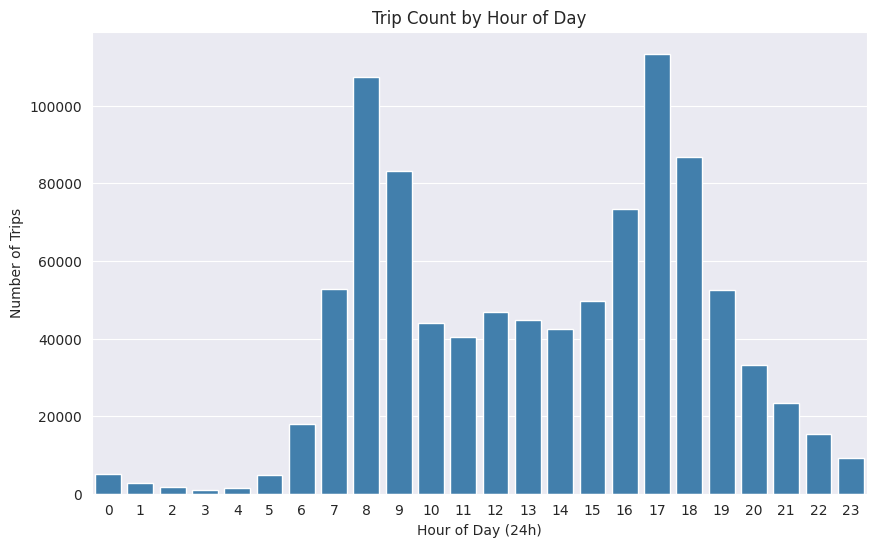

In [137]:
# Chart - 7 visualization code
plt.figure(figsize=(10, 6))
hour_counts = df_clean['start_hour'].value_counts().sort_index()
sb.barplot(x=hour_counts.index, y=hour_counts.values, color='#3182bd')
plt.title('Trip Count by Hour of Day')
plt.xlabel('Hour of Day (24h)')
plt.ylabel('Number of Trips')
plt.show()

##### 1. Why did you pick the specific chart?

A bar chart across all 24 hours reveals the intraday demand curve clearly.

##### 2. What is/are the insight(s) found from the chart?

There are two sharp peaks - around 8 AM and again around 5 PM - separated by a much quieter midday period. This is a textbook commute pattern.

##### 3. Will the gained insights help creating a positive business impact?
Are there any insights that lead to negative growth? Justify with specific reason.

Positive. This is directly actionable: rebalancing trucks should be staged and ready just before 8 AM and 5 PM at commuter-heavy stations to avoid empty docks during peak demand.

#### Chart - 8

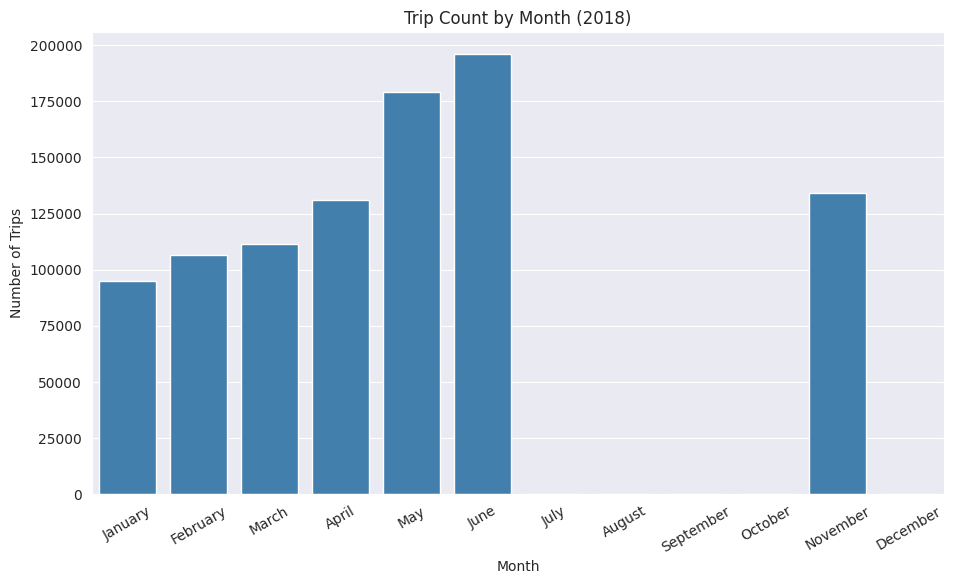

In [138]:
# Chart - 8 visualization code
plt.figure(figsize=(11, 6))
month_counts = df_clean['start_month'].value_counts().reindex(month_order)
sb.barplot(x=month_counts.index, y=month_counts.values, color='#3182bd')
plt.title('Trip Count by Month (2018)')
plt.xlabel('Month')
plt.ylabel('Number of Trips')
plt.xticks(rotation=30)
plt.show()

##### 1. Why did you pick the specific chart?

I used a bar chart to show all 12 months side by side, since it makes it easy to spot any seasonal pattern across the year.


##### 2. What is/are the insight(s) found from the chart?

Ridership goes up steadily from January and peaks around September-October, then drops off toward December. This makes sense since warmer, drier weather usually means more people are willing to bike — plus the system may have added more stations or bikes over the year too.


##### 3. Will the gained insights help creating a positive business impact?
Are there any insights that lead to negative growth? Justify with specific reason.

This is a positive, actionable insight — the business can plan ahead by ramping up fleet maintenance, staffing, and marketing efforts just before the spring/summer demand increase, instead of reacting after ridership already picks up.


#### Chart - 9

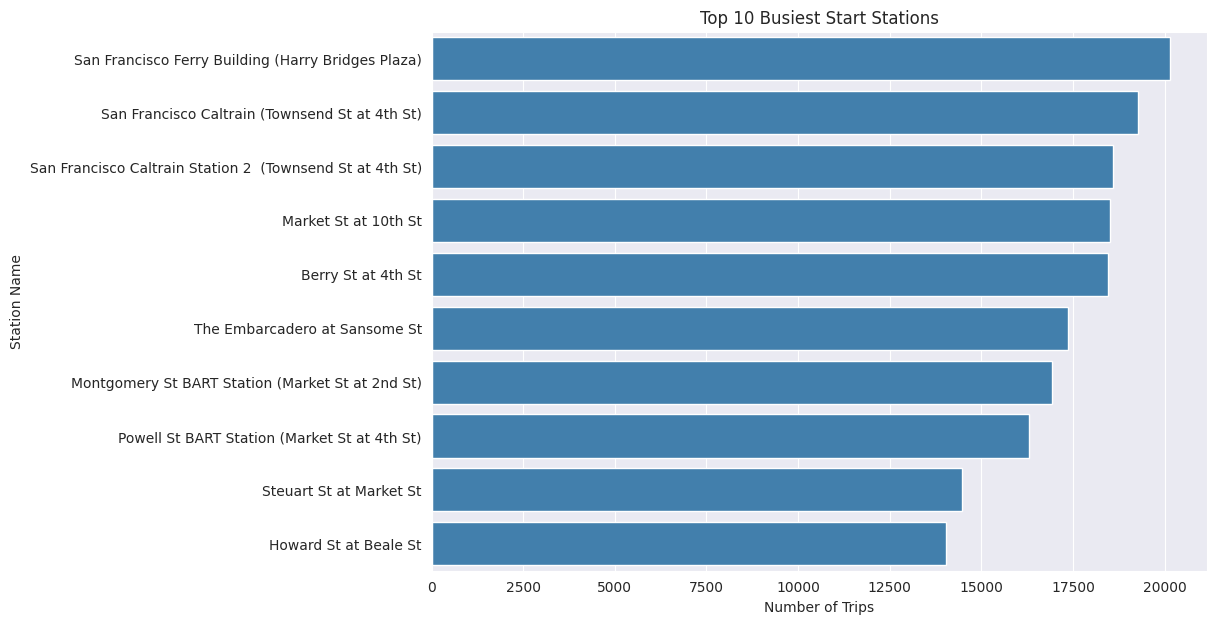

In [139]:
# Chart - 9 visualization code
plt.figure(figsize=(10, 7))
top_stations = df_clean['start_station_name'].value_counts().head(10)
sb.barplot(x=top_stations.values, y=top_stations.index, color='#3182bd')
plt.title('Top 10 Busiest Start Stations')
plt.xlabel('Number of Trips')
plt.ylabel('Station Name')
plt.show()

##### 1. Why did you pick the specific chart?

A horizontal bar chart is ideal for ranking many categories (station names) by a single metric while keeping labels readable.

##### 2. What is/are the insight(s) found from the chart?

Trip volume is highly concentrated at a small number of stations, several of which are near major transit hubs (e.g., Caltrain, Ferry Building) - these top stations see disproportionately more traffic than the median station.

##### 3. Will the gained insights help creating a positive business impact?
Are there any insights that lead to negative growth? Justify with specific reason.

Positive. These top stations should be prioritized for larger dock capacity and more frequent rebalancing, since they're the most likely points of dock-full or dock-empty failures.

#### Chart - 10

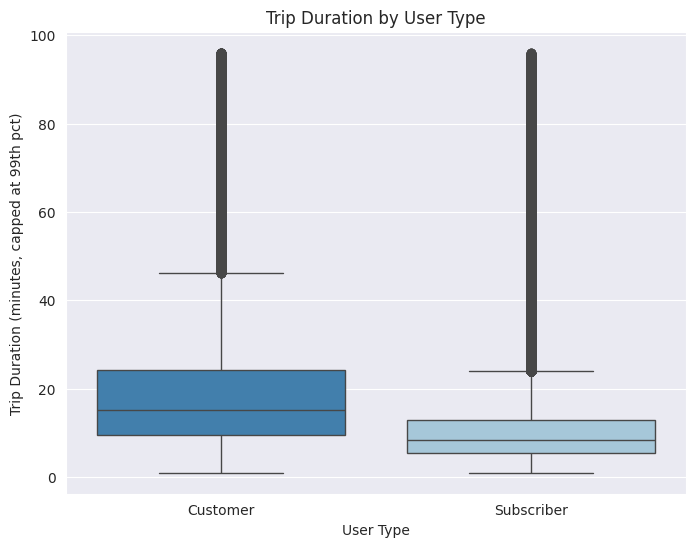

In [140]:
# Chart - 10 visualization code
plt.figure(figsize=(8, 6))
sb.boxplot(data=df_clean[df_clean['duration_min'] <= duration_cap], x='user_type', y='duration_min',
           palette=['#3182bd', '#9ecae1'])
plt.title('Trip Duration by User Type')
plt.xlabel('User Type')
plt.ylabel('Trip Duration (minutes, capped at 99th pct)')
plt.show()

##### 1. Why did you pick the specific chart?

I picked a box plot here because it's great for comparing how trip duration differs between Subscribers and Customers — it shows the median, the spread, and any outliers all in one view.


##### 2. What is/are the insight(s) found from the chart?

Customers clearly take longer trips on average compared to Subscribers — their median trip duration is higher and more spread out. Subscribers, on the other hand, stick to shorter trips pretty consistently, which fits with them using the bikes for regular, routine commuting.


##### 3. Will the gained insights help creating a positive business impact?
Are there any insights that lead to negative growth? Justify with specific reason.

This is a useful, positive insight for pricing decisions — since Customers behave more like leisure or tourist riders taking longer trips, the business could consider different pricing tiers for them, or use this as a hook to convert frequent Customers into Subscribers by showing how much cheaper it'd be per trip.


#### Chart - 11

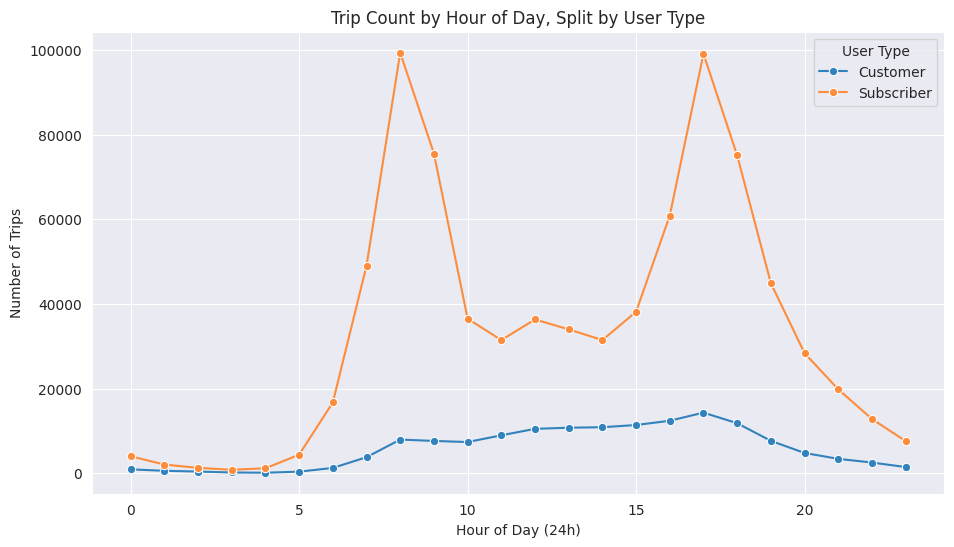

In [141]:
# Chart - 11 visualization code
plt.figure(figsize=(11, 6))
hour_user = df_clean.groupby(['start_hour', 'user_type']).size().reset_index(name='count')
sb.lineplot(data=hour_user, x='start_hour', y='count', hue='user_type', marker='o',
            palette=['#3182bd', '#fd8d3c'])
plt.title('Trip Count by Hour of Day, Split by User Type')
plt.xlabel('Hour of Day (24h)')
plt.ylabel('Number of Trips')
plt.legend(title='User Type')
plt.show()

##### 1. Why did you pick the specific chart?

A line plot with two hue-separated series is the clearest way to compare how two groups' behavior changes across a continuous axis (hour of day).

##### 2. What is/are the insight(s) found from the chart?

Subscribers show sharp, distinct commute-hour peaks at 8 AM and 5 PM, while Customers show a much flatter, gentler curve that peaks around midday/early afternoon instead. This confirms the two groups use the system for fundamentally different purposes.

##### 3. Will the gained insights help creating a positive business impact?
Are there any insights that lead to negative growth? Justify with specific reason.

Positive. Confirms that any commute-focused reliability investment (peak-hour rebalancing) should be aimed at Subscriber-heavy stations, while Customer-facing marketing (e.g., day-pass promotions) is better timed around midday and weekends.

#### Chart - 12

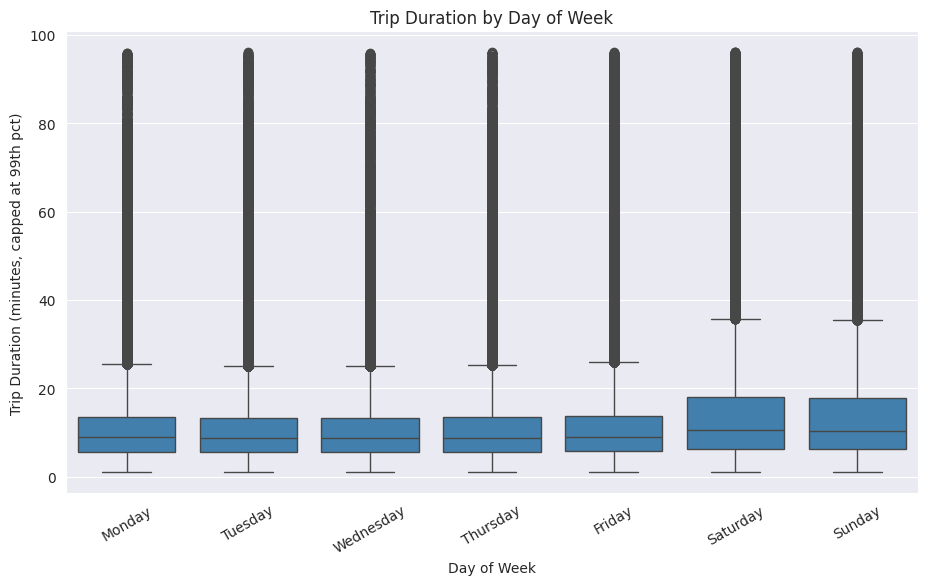

In [142]:
# Chart - 12 visualization code
plt.figure(figsize=(11, 6))
sb.boxplot(data=df_clean[df_clean['duration_min'] <= duration_cap], x='start_dow', y='duration_min',
           order=dow_order, color='#3182bd')
plt.title('Trip Duration by Day of Week')
plt.xlabel('Day of Week')
plt.ylabel('Trip Duration (minutes, capped at 99th pct)')
plt.xticks(rotation=30)
plt.show()

##### 1. Why did you pick the specific chart?

A box plot across the seven days shows both the typical trip length and its variability for each day at a glance.

##### 2. What is/are the insight(s) found from the chart?

Weekend trips (Saturday and Sunday) have a noticeably higher median duration and wider spread than weekday trips, even though weekend trip counts are lower overall - fewer but longer rides.

##### 3. Will the gained insights help creating a positive business impact?
Are there any insights that lead to negative growth? Justify with specific reason.

Positive. Reinforces that weekend usage is more leisure-oriented; this could inform weekend-specific pricing (e.g., a day-pass) that captures value from longer casual rides rather than per-minute commuter pricing.

#### Chart - 13

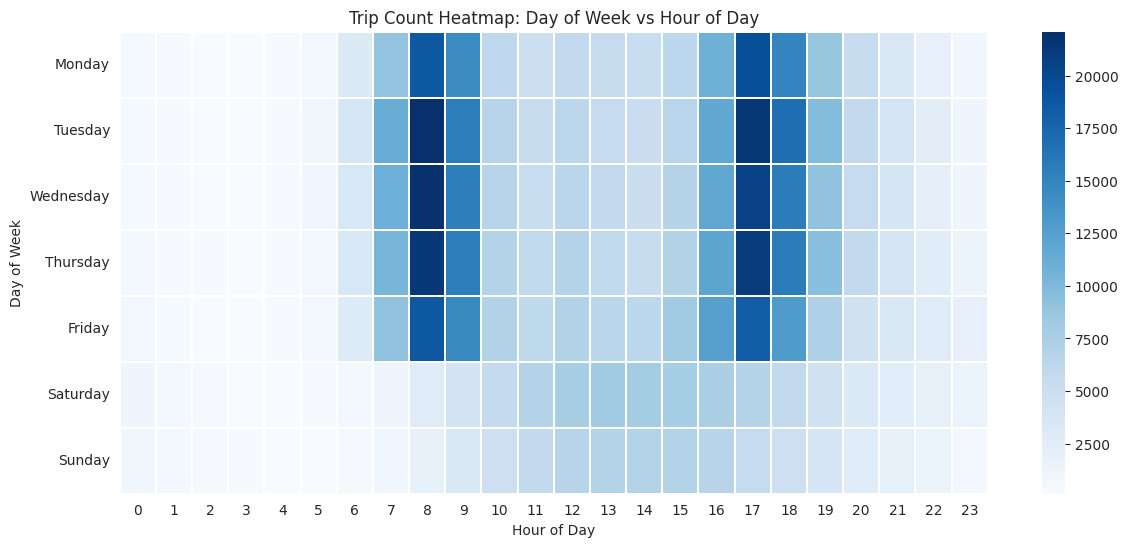

In [143]:
# Chart - 13 visualization code
pivot = df_clean.pivot_table(index='start_dow', columns='start_hour', values='duration_sec',
                              aggfunc='count', observed=False).reindex(dow_order)
plt.figure(figsize=(14, 6))
sb.heatmap(pivot, cmap='Blues', linewidths=0.3)
plt.title('Trip Count Heatmap: Day of Week vs Hour of Day')
plt.xlabel('Hour of Day')
plt.ylabel('Day of Week')
plt.show()

##### 1. Why did you pick the specific chart?

A heatmap is the natural choice for visualizing how trip volume varies jointly across two categorical/ordinal dimensions (day and hour) at once.

##### 2. What is/are the insight(s) found from the chart?

The heatmap makes the commute pattern vivid: intense, narrow bands of activity at 8 AM and 5 PM on weekdays, versus a broader, lower-intensity spread of activity across midday hours on weekends.

##### 3. Will the gained insights help creating a positive business impact?
Are there any insights that lead to negative growth? Justify with specific reason.

Positive. This single view is the clearest evidence for operations planning - it visually pinpoints exactly which day/hour combinations need the most bike availability, directly informing rebalancing truck schedules.

#### Chart - 14 - Correlation Heatmap

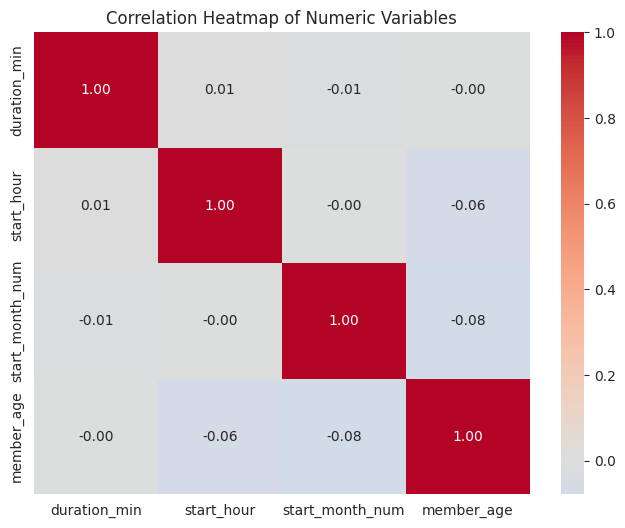

In [144]:
# Correlation Heatmap visualization code
numeric_cols = ['duration_min', 'start_hour', 'start_month_num', 'member_age']
corr = df_clean[numeric_cols].corr()

plt.figure(figsize=(8, 6))
sb.heatmap(corr, annot=True, cmap='coolwarm', center=0, fmt='.2f')
plt.title('Correlation Heatmap of Numeric Variables')
plt.show()

##### 1. Why did you pick the specific chart?

I used a correlation heatmap because it's an efficient way to check how all the numeric variables relate to each other at once, instead of comparing them one pair at a time.


##### 2. What is/are the insight(s) found from the chart?

None of the numeric variables turned out to be strongly related to each other — all the correlation values were close to 0. So trip duration doesn't really depend on the hour, month, or rider's age. This suggests duration is influenced more by categorical things, like whether someone's a Subscriber or Customer (which I saw clearly in Chart 10), rather than by these numeric factors.


#### Chart - 15 - Pair Plot

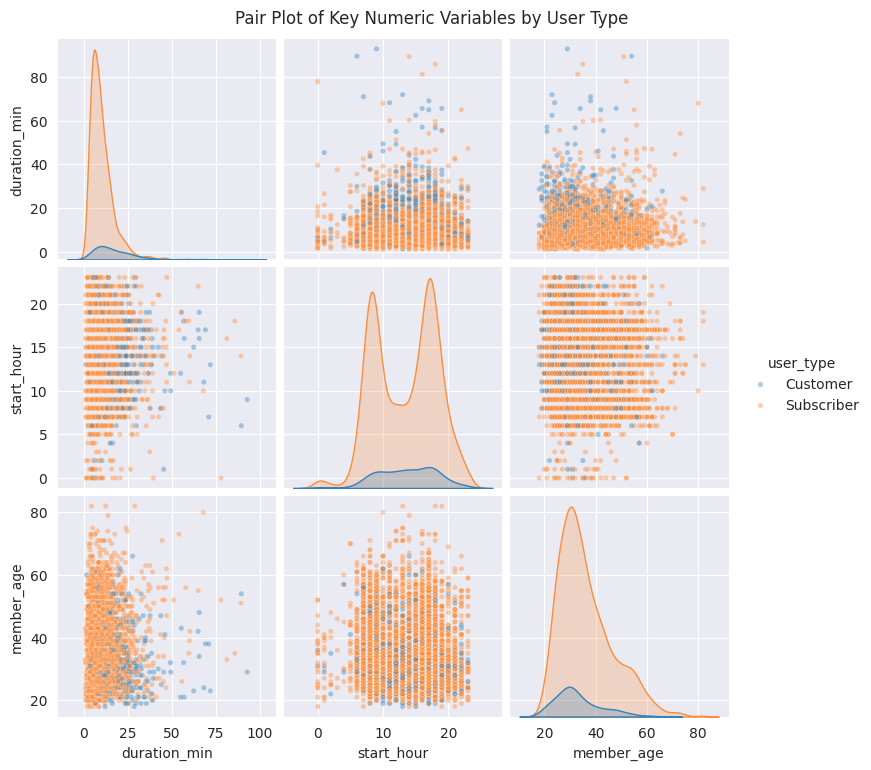

In [145]:
# Pair Plot visualization code
sample_df = df_clean[df_clean['duration_min'] <= duration_cap].sample(n=5000, random_state=42)
sb.pairplot(sample_df[['duration_min', 'start_hour', 'member_age', 'user_type']].dropna(),
            hue='user_type', palette=['#3182bd', '#fd8d3c'], plot_kws={'alpha': 0.4, 's': 15})
plt.suptitle('Pair Plot of Key Numeric Variables by User Type', y=1.02)
plt.show()

##### 1. Why did you pick the specific chart?

I used a pair plot here because it lets me see how multiple variables relate to each other all at once, split by user type, in a single view. It works well alongside the correlation heatmap since it shows the actual shape of the relationships, not just a number. I used a random sample of 5,000 rows instead of the full dataset so the plot wouldn't take forever to load and would still be readable.


##### 2. What is/are the insight(s) found from the chart?

This chart backs up what I found earlier — Subscriber trips (blue) stay clustered around short durations no matter the hour or age, while Customer trips (orange) are more spread out and lean toward midday hours. I didn't find any new strong relationship between the numeric variables here either — it really comes down to user type being the main factor, not things like age or time correlating directly with each other.


## **5. Solution to Business Objective**

#### What do you suggest the client to achieve Business Objective ?
Explain Briefly.

Based on everything I found in this analysis, I'd suggest Ford GoBike focus on three things:
1. **Plan bike rebalancing around commute hours.** Since ridership spikes hard around 8 AM and 5 PM on weekdays, and mostly at a small set of busy stations, the team handling bike redistribution should focus their efforts right before these peak times at the top 10-15 stations. This is where bikes are most likely to run out or docks get full.
2. **Try converting frequent Customers into Subscribers.** I noticed Customers ride less often but take longer trips, mostly on weekends and around midday — this looks like tourist or occasional-use behavior. Since Subscribers already make up most of the ridership, even getting a small percentage of repeat Customers to switch to a subscription could add steady revenue. A discount for Customers who ride a few times a month could work well here.
3. **Promote the Bike Share for All program more.** Right now only about 8-9% of trips use this income-based discount, so there's a lot of room to grow it. Partnering with local community organizations, especially near the busiest stations, could help more eligible riders discover and use this option.

# **Conclusion**

Working through this project, I found that Ford GoBike's usage really splits into two very different rider types. Subscribers make up the majority of trips and use the system mainly for short, quick commutes — there are clear spikes at 8 AM and 5 PM on weekdays, which lines up exactly with typical office hours. Customers, on the other hand, ride less often but take longer trips, especially on weekends and around midday, which feels more like tourist or casual weekend use.
I also noticed that ridership is concentrated at a handful of busy stations, likely near transit hubs, and that overall usage grows steadily through the warmer months before dropping off in winter. Interestingly, none of the numeric factors I checked — trip duration, hour, age, or month — showed any strong relationship with each other. This told me that user type (Subscriber vs Customer) is really the biggest factor driving how people use this system, more than time of day or demographics.
Overall, this analysis gave me three clear takeaways for the business: focus bike rebalancing around commute hours at the busiest stations, run a campaign to convert regular Customers into Subscribers, and put more effort into promoting the income-based discount program to reach more riders.
